In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objs as go
from plotly.offline import download_plotlyjs, init_notebook_mode, plot, iplot
import cufflinks as cf
cf.go_offline()
init_notebook_mode(connected=True)
%matplotlib inline


In [14]:
df=pd.read_csv("/kaggle/input/world-happy-2019/world-happiness-report-2019.csv")

In [15]:
df.head()

,Country (region),Ladder,SD of Ladder,Positive affect,Negative affect,Social support,Freedom,Corruption,Generosity,Log of GDP\nper capita,Healthy life\nexpectancy
0,Finland,1,4,41.0,10.0,2.0,5.0,4.0,47.0,22.0,27.0
1,Denmark,2,13,24.0,26.0,4.0,6.0,3.0,22.0,14.0,23.0
2,Norway,3,8,16.0,29.0,3.0,3.0,8.0,11.0,7.0,12.0
3,Iceland,4,9,3.0,3.0,1.0,7.0,45.0,3.0,15.0,13.0
4,Netherlands,5,1,12.0,25.0,15.0,19.0,12.0,7.0,12.0,18.0


<h1>Correlation Matrix</h1>

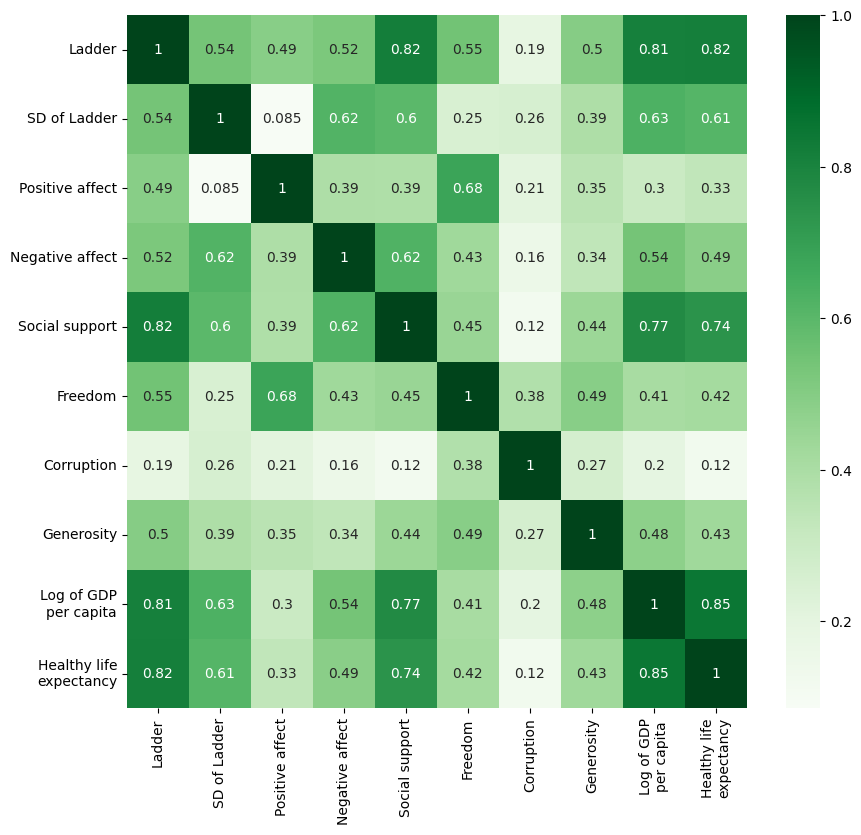

In [16]:
numeric_df = df.select_dtypes(include=[np.number])
plt.figure(figsize=(10, 9))
sns.heatmap(numeric_df.corr(), cmap="Greens", annot=True)
plt.show()

<h1>Generalizing the dataset more by introducing a new column of Continent.</h1>

In [17]:
asia = ["Israel", "United Arab Emirates", "Singapore", "Thailand", "Taiwan Province of China",
                 "Qatar", "Saudi Arabia", "Kuwait", "Bahrain", "Malaysia", "Uzbekistan", "Japan",
                 "South Korea", "Turkmenistan", "Kazakhstan", "Turkey", "Hong Kong S.A.R., China", "Philippines",
                 "Jordan", "China", "Pakistan", "Indonesia", "Azerbaijan", "Lebanon", "Vietnam",
                 "Tajikistan", "Bhutan", "Kyrgyzstan", "Nepal", "Mongolia", "Palestinian Territories",
                 "Iran", "Bangladesh", "Myanmar", "Iraq", "Sri Lanka", "Armenia", "India", "Georgia",
                 "Cambodia", "Afghanistan", "Yemen", "Syria"]
europe = ["Norway", "Denmark", "Iceland", "Switzerland", "Finland",
                 "Netherlands", "Sweden", "Austria", "Ireland", "Germany",
                 "Belgium", "Luxembourg", "United Kingdom", "Czech Republic",
                 "Malta", "France", "Spain", "Slovakia", "Poland", "Italy",
                 "Russia", "Lithuania", "Latvia", "Moldova", "Romania",
                 "Slovenia", "North Cyprus", "Cyprus", "Estonia", "Belarus",
                 "Serbia", "Hungary", "Croatia", "Kosovo", "Montenegro",
                 "Greece", "Portugal", "Bosnia and Herzegovina", "Macedonia",
                 "Bulgaria", "Albania", "Ukraine"]
north_america = ["Canada", "Costa Rica", "United States", "Mexico",  
                 "Panama","Trinidad and Tobago", "El Salvador", "Belize", "Guatemala",
                 "Jamaica", "Nicaragua", "Dominican Republic", "Honduras",
                 "Haiti"]
south_america = ["Chile", "Brazil", "Argentina", "Uruguay",
                 "Colombia", "Ecuador", "Bolivia", "Peru",
                 "Paraguay", "Venezuela"]
australia = ["New Zealand", "Australia"]
d_asia = dict.fromkeys(asia, 'Asia')
print(d_asia)
d_europe = dict.fromkeys(europe, 'Europe')
print(d_europe)
d_north_america = dict.fromkeys(north_america, 'North America')
print(d_north_america)
d_south_america = dict.fromkeys(south_america, 'South America')
print(d_south_america)
d_australia = dict.fromkeys(australia, 'Australia')
print(d_australia)
continent_dict = {**d_asia, **d_europe, **d_north_america, **d_south_america, **d_australia}
print(continent_dict)
df["continent"] = df["Country (region)"].map(continent_dict)
df.continent.fillna("Africa", inplace=True)

{'Israel': 'Asia', 'United Arab Emirates': 'Asia', 'Singapore': 'Asia', 'Thailand': 'Asia', 'Taiwan Province of China': 'Asia', 'Qatar': 'Asia', 'Saudi Arabia': 'Asia', 'Kuwait': 'Asia', 'Bahrain': 'Asia', 'Malaysia': 'Asia', 'Uzbekistan': 'Asia', 'Japan': 'Asia', 'South Korea': 'Asia', 'Turkmenistan': 'Asia', 'Kazakhstan': 'Asia', 'Turkey': 'Asia', 'Hong Kong S.A.R., China': 'Asia', 'Philippines': 'Asia', 'Jordan': 'Asia', 'China': 'Asia', 'Pakistan': 'Asia', 'Indonesia': 'Asia', 'Azerbaijan': 'Asia', 'Lebanon': 'Asia', 'Vietnam': 'Asia', 'Tajikistan': 'Asia', 'Bhutan': 'Asia', 'Kyrgyzstan': 'Asia', 'Nepal': 'Asia', 'Mongolia': 'Asia', 'Palestinian Territories': 'Asia', 'Iran': 'Asia', 'Bangladesh': 'Asia', 'Myanmar': 'Asia', 'Iraq': 'Asia', 'Sri Lanka': 'Asia', 'Armenia': 'Asia', 'India': 'Asia', 'Georgia': 'Asia', 'Cambodia': 'Asia', 'Afghanistan': 'Asia', 'Yemen': 'Asia', 'Syria': 'Asia'}
{'Norway': 'Europe', 'Denmark': 'Europe', 'Iceland': 'Europe', 'Switzerland': 'Europe', 'Finla

/tmp/ipykernel_33/1842669224.py:38: FutureWarning:

A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.





In [18]:
df.head()

,Country (region),Ladder,SD of Ladder,Positive affect,Negative affect,Social support,Freedom,Corruption,Generosity,Log of GDP\nper capita,Healthy life\nexpectancy,continent
0,Finland,1,4,41.0,10.0,2.0,5.0,4.0,47.0,22.0,27.0,Europe
1,Denmark,2,13,24.0,26.0,4.0,6.0,3.0,22.0,14.0,23.0,Europe
2,Norway,3,8,16.0,29.0,3.0,3.0,8.0,11.0,7.0,12.0,Europe
3,Iceland,4,9,3.0,3.0,1.0,7.0,45.0,3.0,15.0,13.0,Europe
4,Netherlands,5,1,12.0,25.0,15.0,19.0,12.0,7.0,12.0,18.0,Europe


In [19]:
asias = df[df['continent'] == "Asia"]
europe  = df[df['continent'] == "Europe"]
north_am = df[df['continent'] == "North America"]
south_am = df[df['continent'] == "South America"]

<h1>Comparing Asia with other Continents and finding insights</h1>

In [20]:


asias_numeric = asias.select_dtypes(include=[np.number])
europe_numeric = europe.select_dtypes(include=[np.number])
south_am_numeric = south_am.select_dtypes(include=[np.number])
north_am_numeric = north_am.select_dtypes(include=[np.number])

# Compute means
data = [
    asias_numeric.mean().values,
    europe_numeric.mean().values,
    south_am_numeric.mean().values,
    north_am_numeric.mean().values
]

# Create DataFrame
dataframe = pd.DataFrame(data=data, columns=asias_numeric.mean().index)

# Select relevant columns
df_first = dataframe[['Ladder', 'Positive affect', 'Negative affect', 'Social support']]

# Verify result
print(df_first)

      Ladder  Positive affect  Negative affect  Social support
0  86.243902        89.825000        76.850000       84.075000
1  43.350000        81.025000        51.225000       38.400000
2  52.800000        34.700000        99.200000       55.400000
3  44.538462        32.153846        73.846154       59.692308


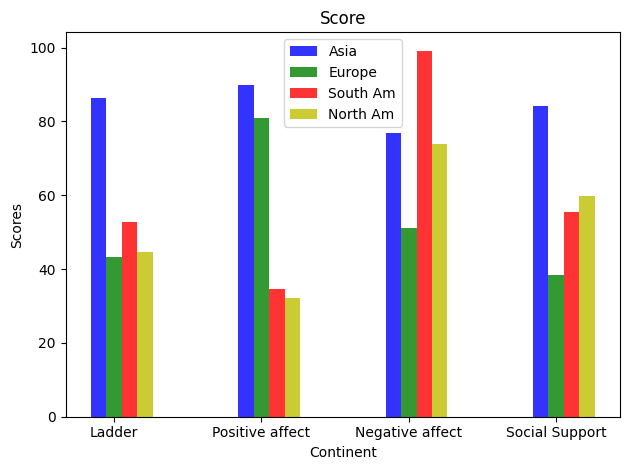

In [21]:
n_groups = 4
asia = df_first.loc[0].values
europe = df_first.loc[1].values
south_am = df_first.loc[2].values
north_am = df_first.loc[3].values
# create plot
fig, ax = plt.subplots()
index = np.linspace(0,10,n_groups)
bar_width = 0.35
opacity = 0.8

rects1 = plt.bar(index, asia, bar_width,
alpha=opacity,
color='b',
label='Asia')

rects2 = plt.bar(index + bar_width, europe, bar_width,
alpha=opacity,
color='g',
label='Europe')

rects3 = plt.bar(index + 2*bar_width, south_am, bar_width,
alpha=opacity,
color='r',
label='South Am')

rects3 = plt.bar(index + 3*bar_width, north_am, bar_width,
alpha=opacity,
color='y',
label='North Am')


plt.xlabel('Continent')
plt.ylabel('Scores')
plt.title('Score')
plt.xticks(index + bar_width, ('Ladder', 'Positive affect', 'Negative affect', 'Social Support'))
plt.legend()

plt.tight_layout()
plt.show()

In [22]:
df_second = dataframe[['Freedom','Corruption','Generosity','Log of GDP\nper capita']]

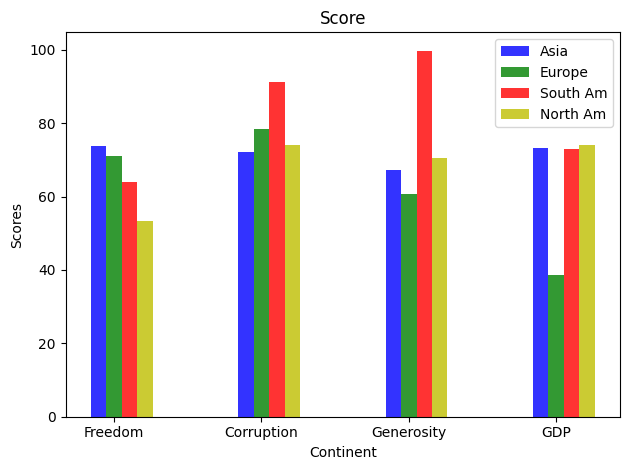

In [23]:
n_groups = 4
asia = df_second.loc[0].values
europe = df_second.loc[1].values
south_am = df_second.loc[2].values
north_am = df_second.loc[3].values
# create plot
fig, ax = plt.subplots()
index = np.linspace(0,10,n_groups)
bar_width = 0.35
opacity = 0.8

rects1 = plt.bar(index, asia, bar_width,
alpha=opacity,
color='b',
label='Asia')

rects2 = plt.bar(index + bar_width, europe, bar_width,
alpha=opacity,
color='g',
label='Europe')

rects3 = plt.bar(index + 2*bar_width, south_am, bar_width,
alpha=opacity,
color='r',
label='South Am')

rects3 = plt.bar(index + 3*bar_width, north_am, bar_width,
alpha=opacity,
color='y',
label='North Am')


plt.xlabel('Continent')
plt.ylabel('Scores')
plt.title('Score')
plt.xticks(index + bar_width, ('Freedom', 'Corruption', 'Generosity', 'GDP'))
plt.legend()

plt.tight_layout()
plt.show()

In [27]:

asias.ffill(inplace=True)


/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning:

use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.



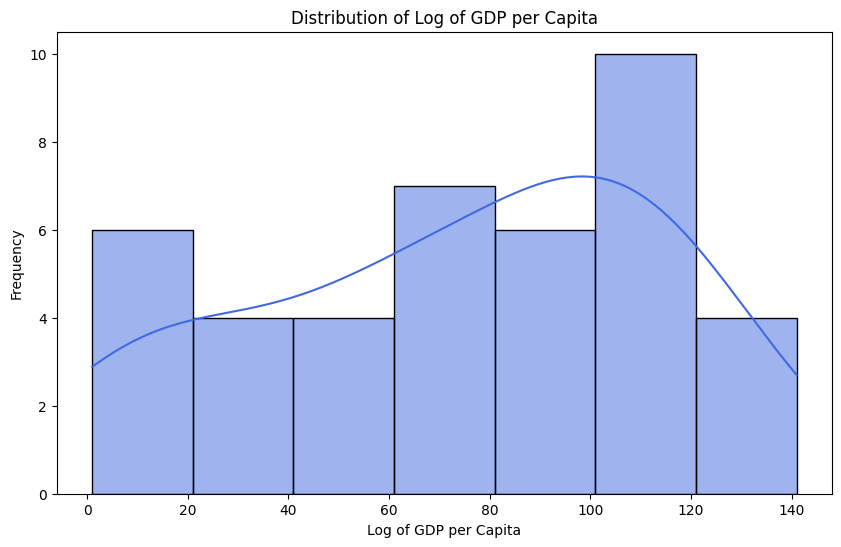

In [29]:
plt.figure(figsize=(10, 6))
sns.histplot(asias['Log of GDP\nper capita'], color='royalblue', kde=True)
plt.title('Distribution of Log of GDP per Capita')
plt.xlabel('Log of GDP per Capita')
plt.ylabel('Frequency')
plt.show()

<h1>Asia specific Correlation</h1>

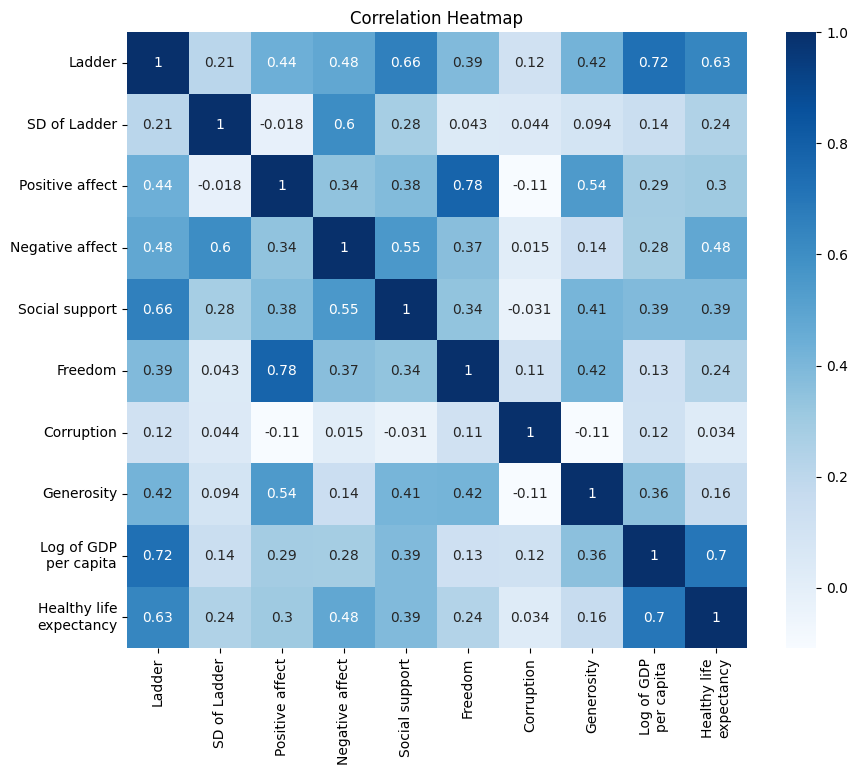

In [31]:
corr_matrix = asias_numeric.corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, cmap="Blues", annot=True)
plt.title('Correlation Heatmap')
plt.show()

**It clearly states that freedom provides asians more positive emotions. That means Asians love when they are free to do something. **

<h1>Visualizing how countries in Asia follow-up Happiness Score</h1>

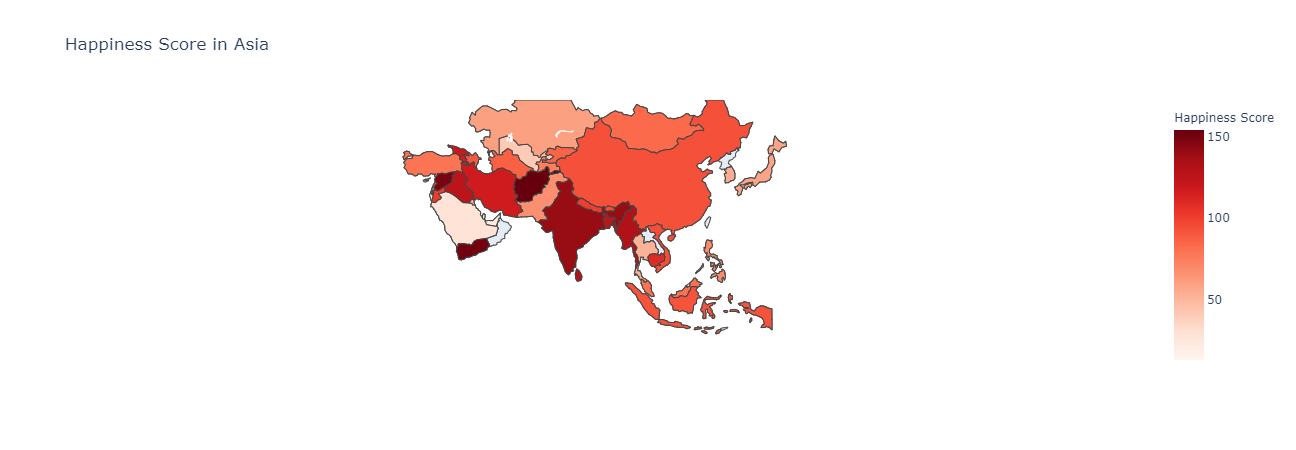

In [32]:
fig = go.Figure(data=go.Choropleth(
    locations=asias['Country (region)'], # Spatial coordinates
    z = asias['Ladder'].astype(float), # Data to be color-coded
    locationmode = 'country names', # set of locations match entries in `locations`
    colorscale = 'Reds',
    colorbar_title = "Happiness Score",
))

fig.update_layout(
    title_text = 'Happiness Score in Asia',
    geo_scope='asia', # limite map scope to asia
)

fig.show()